# Attention by Hand: What Q, K and V Are For

A companion to [`vit_pytorch.ipynb`](vit_pytorch.ipynb).


The attention matrix is given by:
$$
\mathbf{A} = \operatorname{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^{\mathsf{T}}}{\sqrt{m}}\right).
$$

The output of the attention layer is then:
$$
\mathbf{T}_{\texttt{out}} = \mathbf{A}\mathbf{V}.
$$


---
## 1. A scene, and its tokens

Attention operates on tokens. To think about projections, we need tokens whose
dimensions mean something. Here, we build a small scene, and represent each patch
by the following code vector:

$$
\mathbf{t} = \big[\;\underbrace{R,\ G,\ B}_{\text{mean colour}},\;\;
\underbrace{x,\ y}_{\text{position}},\;\;
\underbrace{\|p\|^2}_{x^2 + y^2},\;\;
\underbrace{1}_{\text{constant}}\;\big]^{\mathsf{T}}
\;\in\; \mathbb{R}^{7 \times 1}
$$

The vector's content is as follows:

| Entry | Description |
|---|---|
| $R,\ G,\ B$ | the patch's mean colour, centred on the image's average and then scaled to unit length. A dot product of two of them is therefore the cosine of the angle between them: whether two patches differ from the average colour in the same direction |
| $x,\ y$ | the patch's centre on the grid, scaled to $[-1, 1]$ |
| $\lVert p \rVert^2$ | $x^2 + y^2$, the squared distance from the middle of the image |
| $1$ | a constant, the same in every token |

The last two are carried so that the bilinear form
$\mathbf{t}_i^{\mathsf{T}}\mathbf{S}\mathbf{t}_j$ can reach the squared distance
between two positions,

$$
-\|p_i - p_j\|^2 \;=\; 2\,(x_i x_j + y_i y_j) \;-\; \|p_i\|^2 \;-\; \|p_j\|^2.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

np.set_printoptions(precision=2, suppress=True, linewidth=110)
rng = np.random.default_rng(0)

GRID = 8          # 8 x 8 patches
PATCH = 24        # pixels per patch
SIZE = GRID * PATCH


def make_scene():
    """A small scene: sky, grass, two animals, one flower."""
    img = np.zeros((SIZE, SIZE, 3))
    yy, xx = np.mgrid[0:SIZE, 0:SIZE]

    img[yy < SIZE * 0.45] = to_rgb("#8ec5e8")           # sky
    img[yy >= SIZE * 0.45] = to_rgb("#7fa650")          # grass

    def blob(cy, cx, r, colour):
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 < r ** 2
        img[mask] = to_rgb(colour)

    blob(0.60 * SIZE, 0.25 * SIZE, 0.11 * SIZE, "#8b5a2b")   # animal
    blob(0.70 * SIZE, 0.62 * SIZE, 0.13 * SIZE, "#8b5a2b")   # animal
    blob(0.84 * SIZE, 0.82 * SIZE, 0.14 * SIZE, "#c0392b")   # flower
    return np.clip(img + rng.normal(0, 0.015, img.shape), 0, 1)


image = make_scene()
print(f"image {image.shape}, {GRID}x{GRID} patches of {PATCH}x{PATCH} px -> N = {GRID**2} tokens")

image (192, 192, 3), 8x8 patches of 24x24 px -> N = 64 tokens


In [2]:
FEATURES = ["R", "G", "B", "x", "y", "|p|^2", "1"]
D = len(FEATURES)
N = GRID * GRID


def tokenize(img):
    """One token per patch: mean colour, position, squared radius, constant."""
    patches = img.reshape(GRID, PATCH, GRID, PATCH, 3).mean(axis=(1, 3))   # (GRID, GRID, 3)
    colour = patches.reshape(N, 3)
    colour = colour - colour.mean(0)                     # centre on the image's average colour
    colour /= np.maximum(np.linalg.norm(colour, axis=1, keepdims=True), 1e-8)   # unit length

    gy, gx = np.mgrid[0:GRID, 0:GRID]
    x = (gx.reshape(N) / (GRID - 1)) * 2 - 1             # [-1, 1]
    y = (gy.reshape(N) / (GRID - 1)) * 2 - 1
    r2 = x ** 2 + y ** 2
    ones = np.ones(N)

    return np.column_stack([colour, x, y, r2, ones])     # (N, 7), tokens as ROWS


T = tokenize(image)
patch_rgb = image.reshape(GRID, PATCH, GRID, PATCH, 3).mean(axis=(1, 3)).reshape(N, 3)

REGIONS = {"sky": "#8ec5e8", "grass": "#7fa650", "animal": "#8b5a2b", "flower": "#c0392b"}
DEMO_QUERIES = [int(np.linalg.norm(patch_rgb - np.array(to_rgb(hexc)), axis=1).argmin())
                for hexc in REGIONS.values()]
print("one representative patch per region, found by colour:")
for name, q in zip(REGIONS, DEMO_QUERIES):
    print(f"  {name:7s} patch {q:2d}  (row {q // GRID}, col {q % GRID})")
print()
print(f"T has shape {T.shape}  (tokens as rows, as in notebook 4 section 3.3)")
print(f"\ncolumns: {FEATURES}")
print(f"\ntoken 0  (top-left, sky):  {T[0]}")
print(f"token 36 (an animal):      {T[36]}")

one representative patch per region, found by colour:
  sky     patch  5  (row 0, col 5)
  grass   patch 57  (row 7, col 1)
  animal  patch 44  (row 5, col 4)
  flower  patch 54  (row 6, col 6)

T has shape (64, 7)  (tokens as rows, as in notebook 4 section 3.3)

columns: ['R', 'G', 'B', 'x', 'y', '|p|^2', '1']

token 0  (top-left, sky):  [ 0.03  0.32  0.95 -1.   -1.    2.    1.  ]
token 36 (an animal):      [-0.12 -0.26 -0.96  0.14  0.14  0.04  1.  ]


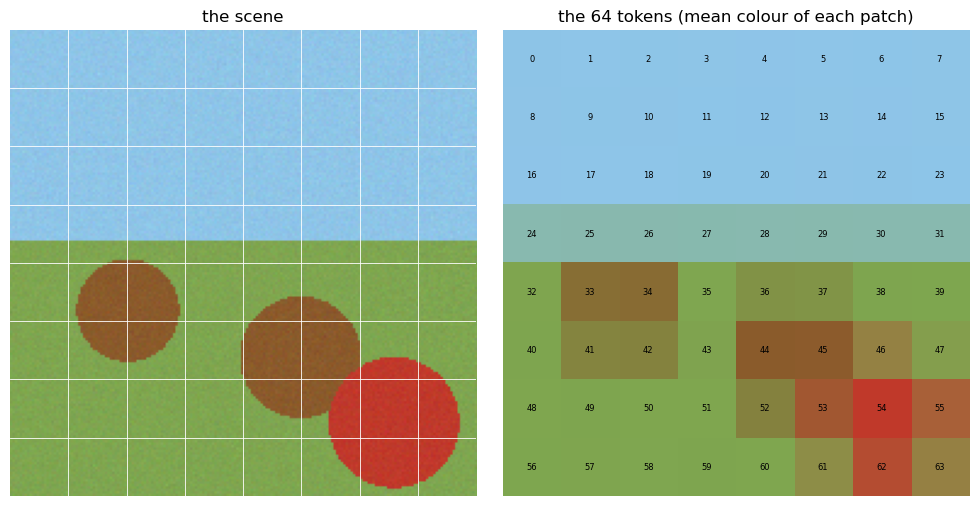

In [3]:
fig, (ax_img, ax_patch) = plt.subplots(1, 2, figsize=(10, 5))
ax_img.imshow(image); ax_img.set_title("the scene"); ax_img.axis("off")
for k in range(1, GRID):
    ax_img.axhline(k * PATCH - 0.5, c="w", lw=0.6)
    ax_img.axvline(k * PATCH - 0.5, c="w", lw=0.6)

ax_patch.imshow(patch_rgb.reshape(GRID, GRID, 3))
ax_patch.set_title(f"the {N} tokens (mean colour of each patch)")
for i in range(N):
    ax_patch.text(i % GRID, i // GRID, str(i), ha="center", va="center", fontsize=6, color="k")
ax_patch.axis("off")
plt.tight_layout(); plt.show()

---
## 2. The attention layer

Here, the layer is written with the projections passed in rather than learned. 

The weight matrices $\mathbf{W}_q$, $\mathbf{W}_k$, and
$\mathbf{W}_v$ enter at three different places and never interact except
through the two products below. 

In [4]:
def softmax_rows(scores):
    shifted = scores - scores.max(axis=1, keepdims=True)    # the shift from notebook 1 section 5
    expd = np.exp(shifted)
    return expd / expd.sum(axis=1, keepdims=True)


def attention(T, Wq, Wk, Wv, scale=None):
    """Scaled dot-product attention with projections."""
    Q = T @ Wq.T                                  # (N, m)   queries
    K = T @ Wk.T                                  # (N, m)   keys
    V = T @ Wv.T                                  # (N, v)   values
    scale = np.sqrt(Q.shape[1]) if scale is None else scale
    A = softmax_rows(Q @ K.T / scale)             # (N, N)   attention matrix
    return A @ V, A                               # (N, v) output, and A


def selector(dims):
    """A projection that simply picks out the named feature dimensions."""
    W = np.zeros((len(dims), D))
    for row, name in enumerate(dims):
        W[row, FEATURES.index(name)] = 1.0
    return W


print("selector(['R','G','B']) picks the colour dimensions:")
print(selector(["R", "G", "B"]))

selector(['R','G','B']) picks the colour dimensions:
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]]


---
## 3. Designing the similarity

We want each patch to attend to patches of **similar colour**,
so queries and keys should carry colour and ignore everything else:

$$
\mathbf{W}_q = \mathbf{W}_k = \texttt{selector}([R, G, B]) \in \mathbb{R}^{3 \times 7}
$$

Then $\mathbf{q}_i^{\mathsf{T}}\mathbf{k}_j$ is the dot product of two centred
colours. This value will be large when two patches deviate from the average colour in the same
direction, and negative when they deviate oppositely.

Pick a query patch below and look at the row of $\mathbf{A}$ it produces.

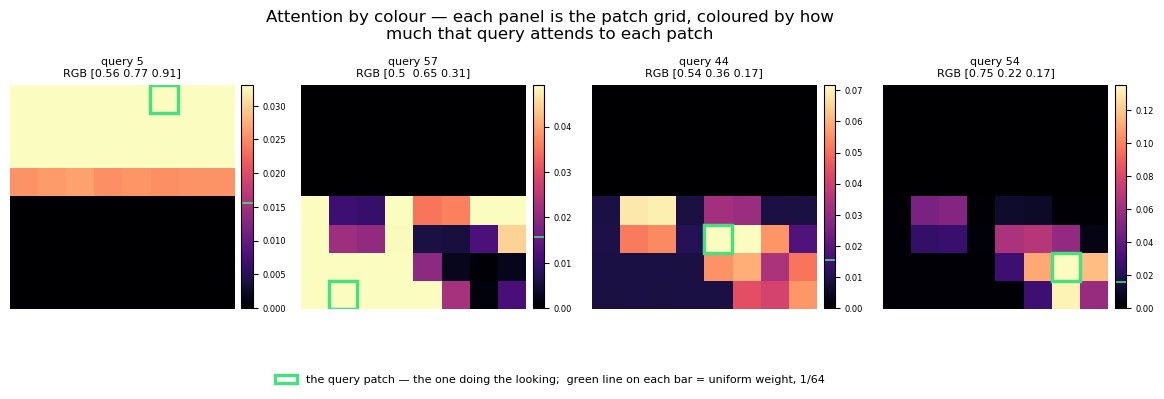

fraction of each query's attention landing on same-coloured patches:
  query  5: 0.794
  query 57: 0.876
  query 44: 0.341
  query 54: 0.267

mean over all 64 queries: 0.680   (uniform attention would give 0.271)


In [5]:
W_colour = selector(["R", "G", "B"])
W_value = selector(["R", "G", "B"])

out_colour, A_colour = attention(T, W_colour, W_colour, W_value, scale=0.1)


QUERY_EDGE = "#4ade80"      # the outline that marks which patch is the query


def show_attention(A, queries, title, rows=1):
    """One panel per query: its row of A, laid back onto the patch grid.

    The panels use the image's own patch layout -- cell (r, c) is image patch
    (r, c) -- but what is coloured is the attention weight, not the patch's
    colour. Each panel is scaled to its own peak, so read the pattern within a
    panel rather than the brightness between panels; its colorbar carries the
    actual weights, and the marked line is the uniform weight 1/N.
    """
    cols = -(-len(queries) // rows)
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.7 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, q in zip(axes, queries):
        im = ax.imshow(A[q].reshape(GRID, GRID), cmap="magma", vmin=0)
        gy, gx = divmod(q, GRID)
        ax.add_patch(plt.Rectangle((gx - 0.5, gy - 0.5), 1, 1,
                                   fill=False, ec=QUERY_EDGE, lw=2.5))
        ax.set_title(f"query {q}\nRGB {np.round(patch_rgb[q], 2)}", fontsize=8)
        ax.axis("off")

        bar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        bar.ax.axhline(1 / N, color=QUERY_EDGE, lw=1.2)
        bar.ax.tick_params(labelsize=6)
    for ax in axes[len(queries):]:
        ax.axis("off")

    key = plt.Rectangle((0, 0), 1, 1, fill=False, ec=QUERY_EDGE, lw=2.5)
    fig.legend([key], ["the query patch — the one doing the looking;  "
                       "green line on each bar = uniform weight, 1/64"],
               loc="lower center", frameon=False, fontsize=8,
               bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(title, y=1.0)
    plt.show()


show_attention(A_colour, DEMO_QUERIES,
               "Attention by colour — each panel is the patch grid, coloured by how\n"
               "much that query attends to each patch")

# Check: For each query, how much of
# its attention lands on patches whose colour is close to its own?
def attention_on_similar(A, tol=0.12):
    colour_distance = np.linalg.norm(patch_rgb[:, None, :] - patch_rgb[None, :, :], axis=-1)
    similar = colour_distance < tol
    return (A * similar).sum(axis=1)

share = attention_on_similar(A_colour)
print(f"fraction of each query's attention landing on same-coloured patches:")
for q in DEMO_QUERIES:
    print(f"  query {q:2d}: {share[q]:.3f}")
print(f"\nmean over all {N} queries: {share.mean():.3f}   (uniform attention would give {np.mean([(np.linalg.norm(patch_rgb - patch_rgb[i], axis=-1) < 0.12).mean() for i in range(N)]):.3f})")

---
## 4. A second head, this time for position

Section 3 built one head by hand: $\mathbf{W}_q$ and $\mathbf{W}_k$ selecting
the colour dimensions, and every patch found the other patches coloured like it.
Now build a **second head** with a different job — each patch should attend to
its spatial *neighbours*, wherever they sit in the image.

The obstacle is that we cannot simply write the projections down. "Select
colour" was easy, because colour occupies three of the token's dimensions and a
selector matrix picks them out. "Attend to whatever is nearby" is not a
selection of dimensions at all, and there is no obvious $\mathbf{W}_q$ for it.

### The fact that makes it possible

Expand a single score, and the two projections collapse into one matrix:

$$
s_{ij} \;=\; \mathbf{q}_i^{\mathsf{T}}\mathbf{k}_j
\;=\; (\mathbf{W}_q \mathbf{t}_i)^{\mathsf{T}} \mathbf{W}_k \mathbf{t}_j
\;=\; \mathbf{t}_i^{\mathsf{T}} \underbrace{\mathbf{W}_q^{\mathsf{T}} \mathbf{W}_k}_{\textstyle \mathbf{S}} \mathbf{t}_j
$$

$\mathbf{S}$ is not a thing any transformer builds. No implementation computes
it, and at $d = 768$ it would be a 590,000-entry matrix where the factored pair
costs $2md$. It is a **lens**, introduced in the chapter's §26.6.3 to say
precisely what a single head can measure, and what it shows is that the queries
and keys never reach the output except through this one product.

That is our way in. **Specify $\mathbf{S}$, then factor it.** Designing a
similarity as a bilinear form is tractable in a way that designing two
projections is not.

### Step 1 — write down the $\mathbf{S}$ we want

The score that makes nearby patches rank high is negative squared distance:

$$
s_{ij} \;=\; -\lVert p_i - p_j \rVert^2 \;=\; 2\,(x_i x_j + y_i y_j) \;-\; \lVert p_i \rVert^2 \;-\; \lVert p_j \rVert^2
$$

Every term on the right is one feature of $\mathbf{t}_i$ multiplied by one
feature of $\mathbf{t}_j$ — exactly the shape
$\mathbf{t}_i^{\mathsf{T}}\mathbf{S}\mathbf{t}_j$ can take. So $\mathbf{S}$ is
four entries, and this is what the $\lVert p \rVert^2$ and constant dimensions
were carried for: the $-\lVert p_i \rVert^2$ term pairs $\lVert p \rVert^2$ in
the query with the constant in the key.

In [6]:
S_local = np.zeros((D, D))
ix, iy, ir2, i1 = (FEATURES.index(f) for f in ("x", "y", "|p|^2", "1"))
S_local[ix, ix] = S_local[iy, iy] = 2.0     #  +2 x_i x_j  +2 y_i y_j
S_local[ir2, i1] = -1.0                     #  -|p_i|^2 * 1
S_local[i1, ir2] = -1.0                     #  -1 * |p_j|^2

# Check it against the distance it is supposed to compute.
scores = T @ S_local @ T.T
positions = T[:, [ix, iy]]
true_negative_sq_distance = -((positions[:, None, :] - positions[None, :, :]) ** 2).sum(-1)
print(f"S reproduces -||p_i - p_j||^2: {np.allclose(scores, true_negative_sq_distance)}")

eigenvalues = np.linalg.eigvalsh(S_local)
print(f"\neigenvalues of S: {np.sort(eigenvalues)}")
print(f"S has a negative eigenvalue: {eigenvalues.min() < -1e-9}")
print("\nAny matrix of the form W^T W is positive semi-definite, so no single")
print("projection can produce this S. Distance is not alignment.")

S reproduces -||p_i - p_j||^2: True

eigenvalues of S: [-1.  0.  0.  0.  1.  2.  2.]
S has a negative eigenvalue: True

Any matrix of the form W^T W is positive semi-definite, so no single
projection can produce this S. Distance is not alignment.


### Step 2 — factor it into a query and a key

$\mathbf{S}$ computes what we asked for. Its eigenvalues report something we did
not ask for: **one of them is negative.**

That rules out tying the two projections together. Any product
$\mathbf{W}^{\mathsf{T}}\mathbf{W}$ is positive semi-definite, so a single
matrix used twice can only ever measure how *aligned* two tokens are — never how
far apart they are. Section 3's colour head got away with one matrix used twice
because alignment was all it needed. This head cannot.

A singular value decomposition supplies the pair, and the rank of $\mathbf{S}$
says how wide the two projections have to be.

rank of S: 4  ->  m = 4 suffices
W_q^T W_k reproduces S: True
W_q equals W_k:         False


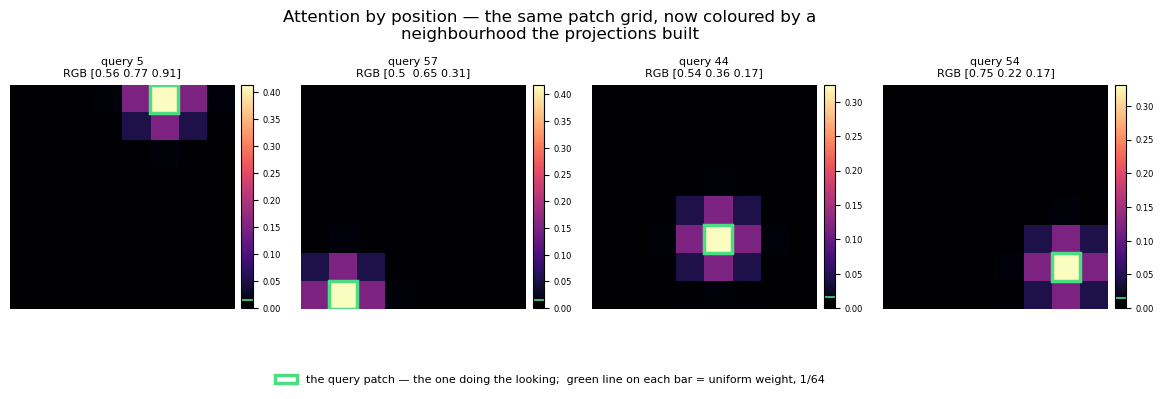

In [7]:
# Factor the indefinite S as W_q^T W_k via its SVD. Two matrices, not one.
U, s, Vt = np.linalg.svd(S_local)
rank = int((s > 1e-9).sum())
Wq_local = (np.sqrt(s[:rank])[:, None] * U[:, :rank].T)
Wk_local = (np.sqrt(s[:rank])[:, None] * Vt[:rank])

print(f"rank of S: {rank}  ->  m = {rank} suffices")
print(f"W_q^T W_k reproduces S: {np.allclose(Wq_local.T @ Wk_local, S_local)}")
print(f"W_q equals W_k:         {np.allclose(Wq_local, Wk_local)}")

_, A_local = attention(T, Wq_local, Wk_local, selector(["R", "G", "B"]), scale=0.08)
show_attention(A_local, DEMO_QUERIES,
               "Attention by position — the same patch grid, now coloured by a\n"
               "neighbourhood the projections built")

Each query now attends to a soft disc around itself. That is a blur kernel — a
convolution — assembled out of an attention layer and a bilinear form we wrote
down in four entries.

Two things the construction establishes:

**$\mathbf{W}_q \neq \mathbf{W}_k$ buys expressiveness, not capacity.** Tying
them forces $\mathbf{S}$ to be positive semi-definite, which confines a head to
measuring alignment. Two separate matrices let $\mathbf{S}$ be any matrix of
rank $m$ — indefinite ones like this, and **asymmetric** ones, where $i$
attending to $j$ is not the same as $j$ attending to $i$.

**Locality is something attention can learn, not something it is given.** A
convolution has it built into its wiring. A transformer has to find it, which is
the cost notebook 4 Section 13 measured.

---
## 5. The same head, written two different ways

We obtained $\mathbf{W}_q$ and $\mathbf{W}_k$ by factoring $\mathbf{S}$ with an
SVD. But a factorization is a *choice*, and the SVD is one of infinitely many.
Any invertible $\mathbf{M}$ gives another: replace $\mathbf{W}_q$ with
$\mathbf{M}^{-\mathsf{T}}\mathbf{W}_q$ and $\mathbf{W}_k$ with
$\mathbf{M}\mathbf{W}_k$, and the two $\mathbf{M}$s cancel inside the product.

If only $\mathbf{S}$ reaches the output, then every one of those pairs has to
behave identically — not similarly, identically. Below is one of them, built
from a random $\mathbf{M}$.

In [8]:
M = rng.normal(size=(rank, rank))
Wq_alt = np.linalg.inv(M).T @ Wq_local      # a different query projection
Wk_alt = M @ Wk_local                       # a different key projection

_, A_alt = attention(T, Wq_alt, Wk_alt, selector(["R", "G", "B"]), scale=0.08)

# This head is zero on the colour dimensions, so show the four it does use.
used = [FEATURES.index(f) for f in ("x", "y", "|p|^2", "1")]
print(f"W_q over the dimensions this head reads, {[FEATURES[i] for i in used]}")
print("  from the SVD:")
print(np.round(Wq_local[:, used], 2))
print("  rebuilt through M:")
print(np.round(Wq_alt[:, used], 2))

print(f"\nthe two projections differ:        {not np.allclose(Wq_local, Wq_alt)}")
print(f"but W_q^T W_k is the same matrix:  {np.allclose(Wq_local.T @ Wk_local, Wq_alt.T @ Wk_alt)}")
print(f"and the attention is identical:    {np.allclose(A_local, A_alt)}")
print(f"largest difference anywhere in A:  {np.abs(A_local - A_alt).max():.2e}")

W_q over the dimensions this head reads, ['x', 'y', '|p|^2', '1']
  from the SVD:
[[1.41 0.   0.   0.  ]
 [0.   1.41 0.   0.  ]
 [0.   0.   1.   0.  ]
 [0.   0.   0.   1.  ]]
  rebuilt through M:
[[-2.    1.82 -0.54  0.71]
 [-1.11  1.44  0.03  0.62]
 [ 0.44  0.07 -0.32 -1.15]
 [-1.37  0.57  0.04  0.43]]

the two projections differ:        True
but W_q^T W_k is the same matrix:  True
and the attention is identical:    True
largest difference anywhere in A:  3.55e-15


That difference is floating-point noise, not approximation. The two layers are
the same layer.

It rules out a reading of the architecture that is tempting and wrong: that
$\mathbf{W}_q$ learns "what token $i$ is looking for" while $\mathbf{W}_k$
learns "what token $j$ has to offer", as two separately meaningful objects.
They are one bilinear form split in two, and the split is arbitrary. Asking what
a trained $\mathbf{W}_q$ means on its own is like asking what the $3$ means in
$12 = 3 \times 4$ — you could as well have written $6 \times 2$. The product is
a property of the model; the factors are an accident of how it was stored.

What the split *does* buy is **rank**. $\mathbf{S}$ is $d \times d$, which at
$d = 768$ would be 590,000 parameters per head. Writing it as
$\mathbf{W}_q^{\mathsf{T}}\mathbf{W}_k$ with $m \ll d$ holds $\mathbf{S}$ to
rank $m$ and costs $2md$ instead. In notebook 4, $d = 64$ and $m = 16$: a
$64 \times 64$ similarity, stored in $2 \times 16 \times 64$ numbers.

---
## 6. $\mathbf{W}_v$ is a different job entirely

Sections 3 to 5 were all about *where to look*. None of them touched
$\mathbf{W}_v$, which decides *what gets carried back*.

The cleanest way to see the separation is to hold $\mathbf{A}$ completely fixed
and change only the value projection. Same attention, three different payloads.

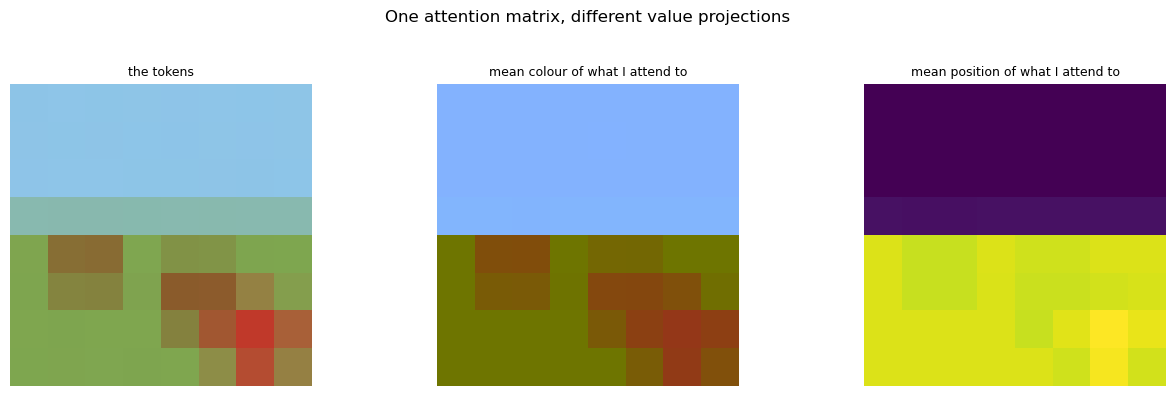

In [9]:
payloads = {
    "mean colour of what I attend to": selector(["R", "G", "B"]),
    "mean position of what I attend to": selector(["x", "y"]),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].imshow(patch_rgb.reshape(GRID, GRID, 3)); axes[0].set_title("the tokens", fontsize=9); axes[0].axis("off")
for ax, (label, Wv) in zip(axes[1:], payloads.items()):
    out = A_colour @ (T @ Wv.T)
    if out.shape[1] == 3:
        shown = np.clip(out - out.min(), 0, None); shown /= max(shown.max(), 1e-9)
        ax.imshow(shown.reshape(GRID, GRID, 3))
    else:
        ax.imshow(out[:, 1].reshape(GRID, GRID), cmap="viridis")
    ax.set_title(label, fontsize=9); ax.axis("off")
fig.suptitle("One attention matrix, different value projections", y=1.03)
plt.tight_layout(); plt.show()

In [10]:
# What happens if we ask it to count? Read the constant feature as the value.
counts = A_colour @ (T @ selector(["1"]).T)

print(f"value = the constant 1, for four different queries:")
for q in DEMO_QUERIES:
    print(f"  query {q:2d}: {counts[q, 0]:.6f}")
print(f"\nevery row of A sums to one: {np.allclose(A_colour.sum(axis=1), 1.0)}")

value = the constant 1, for four different queries:
  query  5: 1.000000
  query 57: 1.000000
  query 44: 1.000000
  query 54: 1.000000

every row of A sums to one: True


Every query returns exactly $1$, whichever patches it attended to. The reason is
the softmax: each row of $\mathbf{A}$ sums to one, so

$$
\mathbf{T}_{\texttt{out}}[i,:] = \sum_j \mathbf{A}[i,j]\, \mathbf{v}_j^{\mathsf{T}}
$$

is a **weighted average** of the values, never a sum. Attention cannot count.

This is worth dwelling on, because the chapter's safari example *does* count —
four animal heads, read out of the output token. It gets away with it because
that figure is drawn with the softmax deliberately left out, so its weights are
$1$ on the attended tokens rather than $\tfrac{1}{4}$ each. Put the softmax
back and the count becomes a mean.

Normalization is what makes attention a pooling operation. You gain stable
magnitudes regardless of sequence length — an output that does not grow as $N$
grows — and you give up the ability to represent *how much* was attended to at
all. If a model needs that quantity it has to smuggle it in some other way.

Three roles, cleanly separated, and now visible:

---
## 7. The scale factor is a temperature

Notebook 4 Section 5.4 argues for the $\sqrt{m}$ from the variance of the dot
product. Here is the same thing to look at.

Divide the scores by a large number and every row of $\mathbf{A}$ approaches
uniform: attention averages everything and distinguishes nothing. Divide by a
small number and each row approaches one-hot: attention becomes a hard lookup
of a single patch.

Attention is a **soft dictionary**, and the scale is its temperature. The
$\sqrt{m}$ is the setting that keeps a freshly initialized model off both
extremes — away from the uniform end where it says nothing, and away from the
saturated end where $\alpha(1-\alpha) \approx 0$ and no gradient flows.

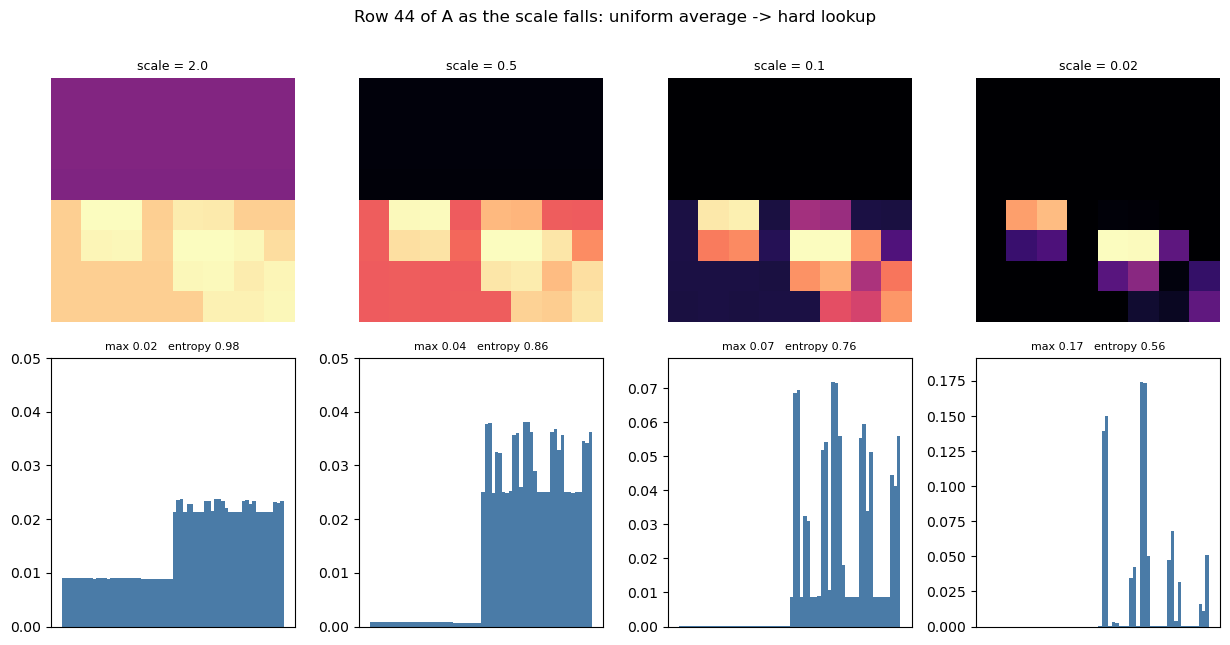

entropy is normalized to [0, 1]: 1 means uniform over all 64 patches,
0 means all the attention sits on one patch.


In [11]:
scales = [2.0, 0.5, 0.1, 0.02]
query = DEMO_QUERIES[2]      # the animal patch

fig, axes = plt.subplots(2, len(scales), figsize=(3.1 * len(scales), 6.4))
for col, scale in enumerate(scales):
    _, A_s = attention(T, W_colour, W_colour, W_value, scale=scale)
    row = A_s[query]

    axes[0, col].imshow(row.reshape(GRID, GRID), cmap="magma", vmin=0)
    axes[0, col].set_title(f"scale = {scale}", fontsize=9); axes[0, col].axis("off")

    entropy = -(row * np.log(row + 1e-12)).sum() / np.log(N)
    axes[1, col].bar(range(N), row, width=1.0, color="#4a7ba7")
    axes[1, col].set_ylim(0, max(row.max() * 1.1, 0.05))
    axes[1, col].set_title(f"max {row.max():.2f}   entropy {entropy:.2f}", fontsize=8)
    axes[1, col].set_xticks([])

fig.suptitle(f"Row {query} of A as the scale falls: uniform average -> hard lookup", y=1.0)
plt.tight_layout(); plt.show()

print("entropy is normalized to [0, 1]: 1 means uniform over all 64 patches,")
print("0 means all the attention sits on one patch.")

---
## 8. What this was for

Everything above ran without a single gradient step. The attention maps came
from choosing which feature dimensions each projection reads, and they are
exactly as interpretable as the choices that produced them.

A trained transformer does the same arithmetic with matrices that are learned.
Notebook 4 Section 11 plots those, and the question to bring to them is the one
this notebook makes askable: **what is this head's $\mathbf{S}$ measuring?**
Alignment of some learned feature? Distance? Something asymmetric, where one
token reads another but not the reverse?

Three things worth carrying forward.

**$\mathbf{W}_q$ and $\mathbf{W}_k$ are one object in two parts.** Only
$\mathbf{S} = \mathbf{W}_q^{\mathsf{T}}\mathbf{W}_k$ affects the output, the
factorization is not unique, and its purpose is to constrain $\mathbf{S}$ to
rank $m$ rather than to give queries and keys separate meanings.

**Two matrices rather than one is about what $\mathbf{S}$ can be.** A single
projection can only produce a positive semi-definite $\mathbf{S}$ — alignment.
Two can produce indefinite and asymmetric ones — distance, and directed
relationships.

**$\mathbf{W}_v$ is independent of both.** Where to look and what to bring back
are separate decisions, which is why multi-head attention can run several
notions of similarity in parallel and still combine their payloads at the end.